In [33]:
%config InlineBackend.figure_format = 'retina'
plt.rcParams['figure.figsize'] = (12, 8)

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import yaml
import matplotlib.cm as cm

def read_cfg (cfg_path : Path) -> dict:
    meta = {"traffic_mode": "unknown", "skew_fraction": None, "skew_partitions": "unknown"}

    if not cfg_path.exists():
        return meta
    try:
        with cfg_path.open("r", encoding = "utf-8") as f:
            yml_file = yaml.safe_load(f) or {}
        data = (yml_file.get("data") or {})
    except Exception:
        return meta
        
    tm = data.get("TRAFFIC_MODE", data.get("traffic_mode", "unknown"))
    sf = data.get("SKEW_FRACTION", data.get("skew_fraction", None))
    sp = data.get("SKEW_PARTITIONS", data.get("SKEW_PARTITION", data.get("skew_partitions", None)))

    meta ["traffic_mode"]    = tm if tm else "unkown"
    meta ["skew_fraction"]   = sf if sf else None
    meta ["skew_partitions"] = sp if sp else None

    return meta
    
def gini(x):
    x = np.array(x)
    if np.amin(x) < 0:
        x = x - np.amin(x)
    x = x + 1e-9  # avoid divide by zero
    x = np.sort(x)
    n = len(x)
    index = np.arange(1, n + 1)
    return ((np.sum((2 * index - n - 1) * x)) / (n * np.sum(x)))

<Figure size 1400x1000 with 0 Axes>

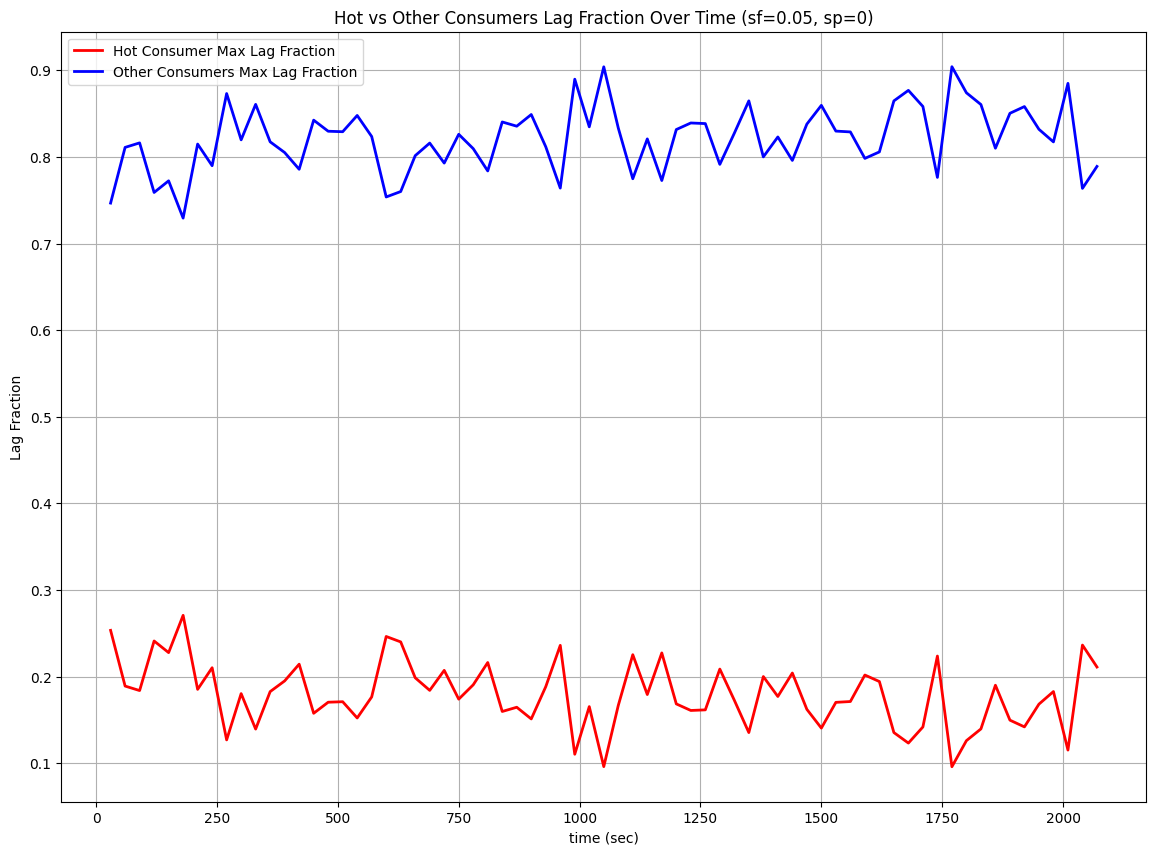

<Figure size 1400x1000 with 0 Axes>

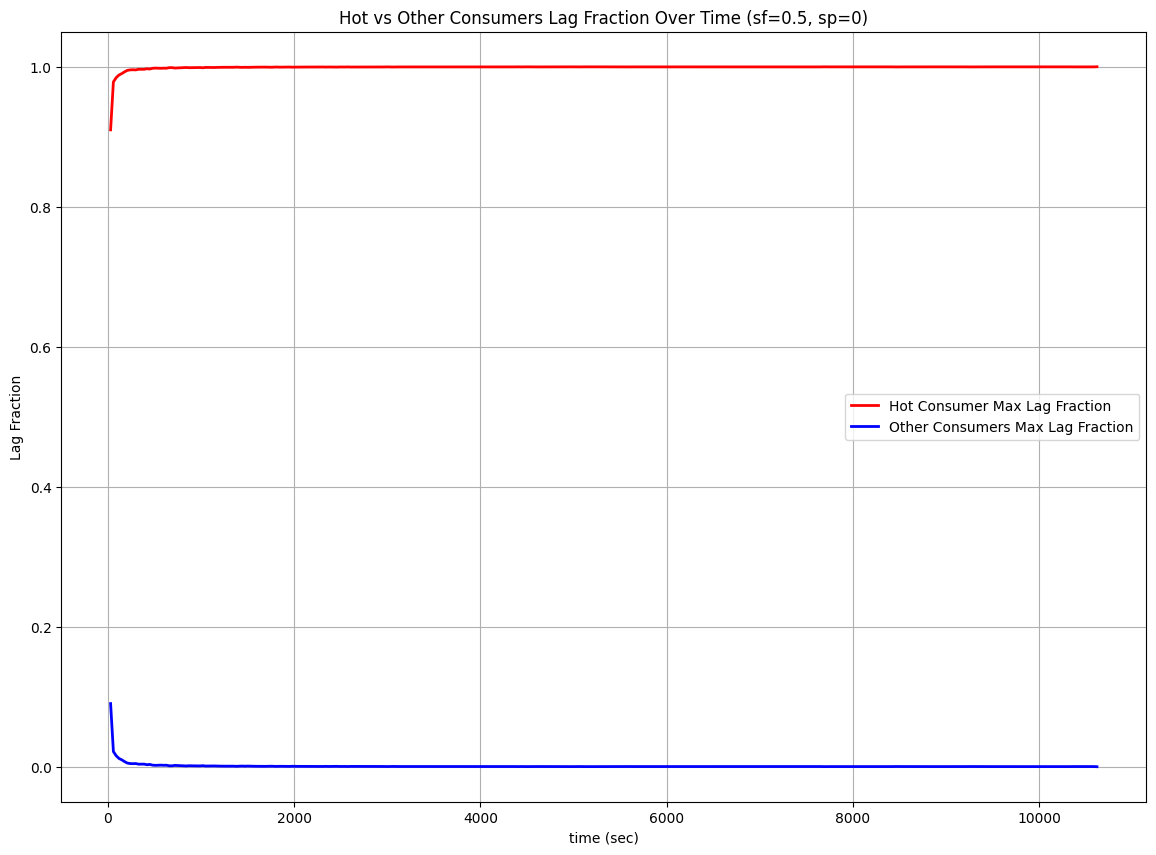

<Figure size 1400x1000 with 0 Axes>

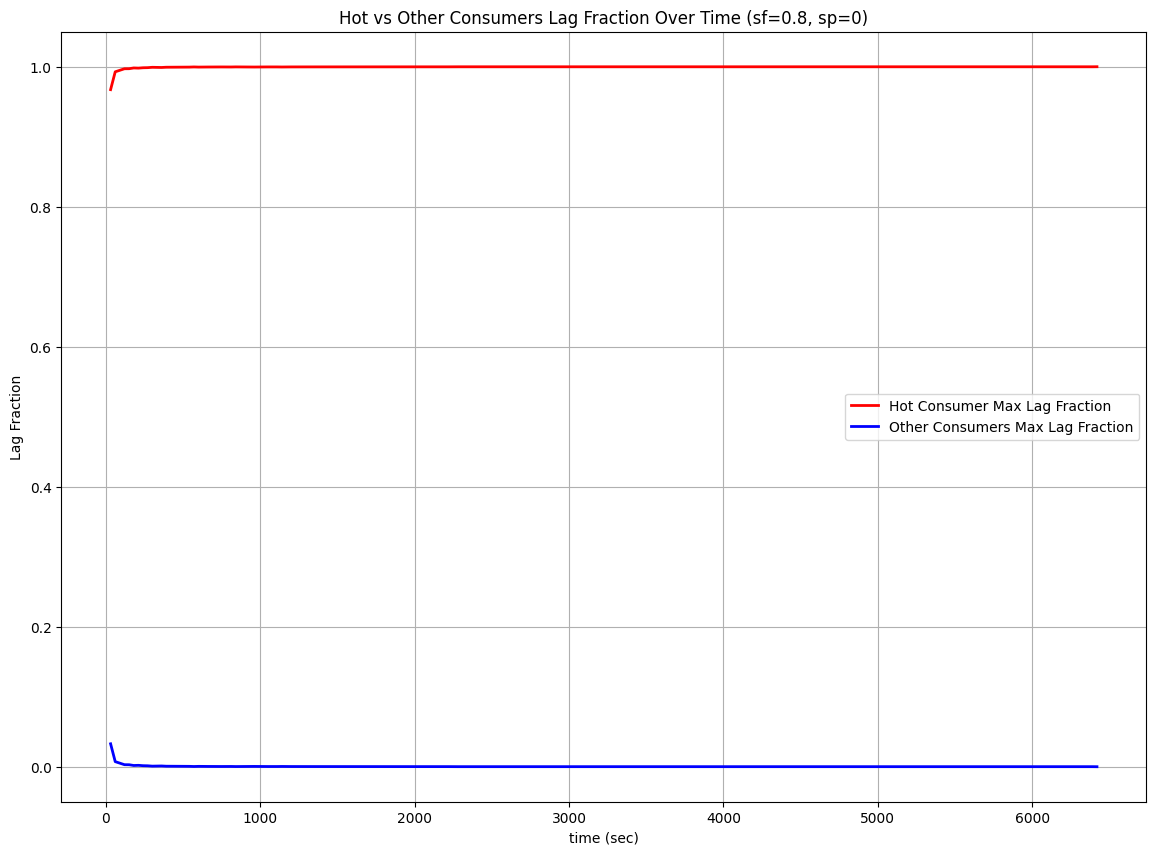

<Figure size 1400x1000 with 0 Axes>

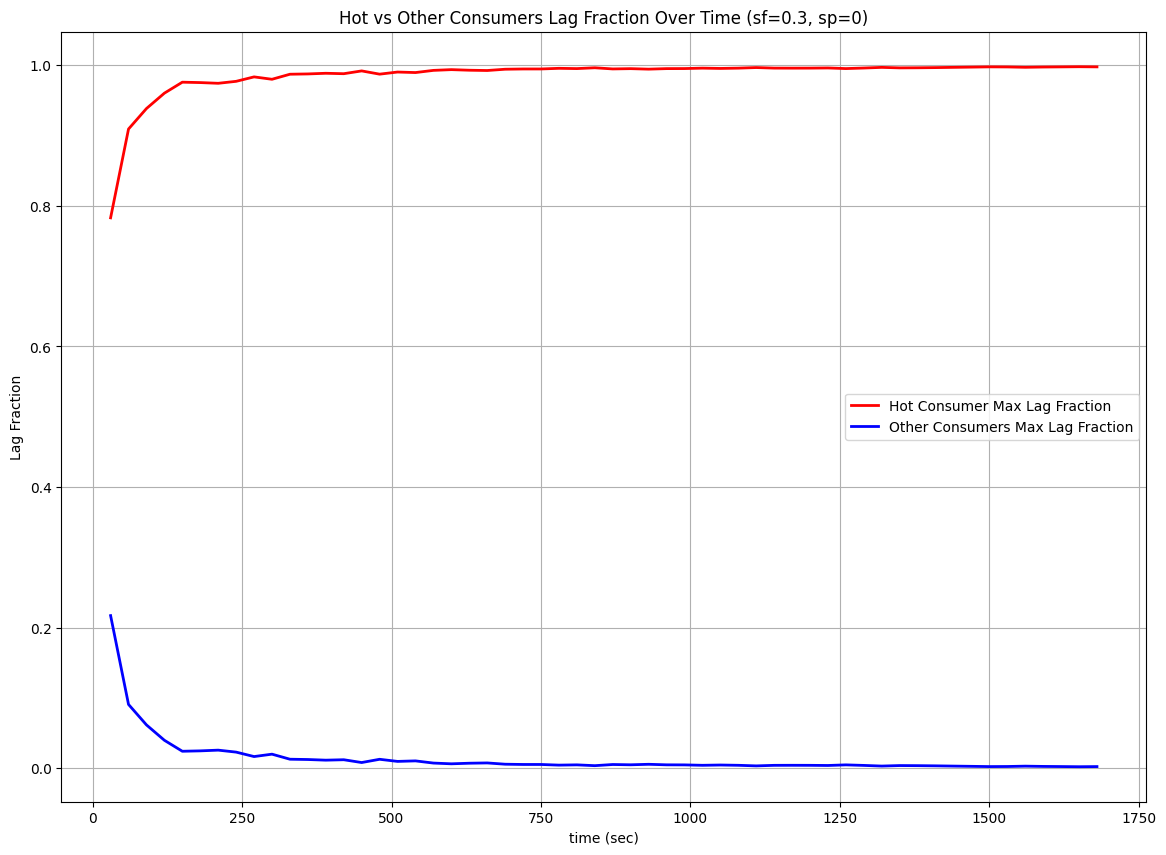

<Figure size 1400x1000 with 0 Axes>

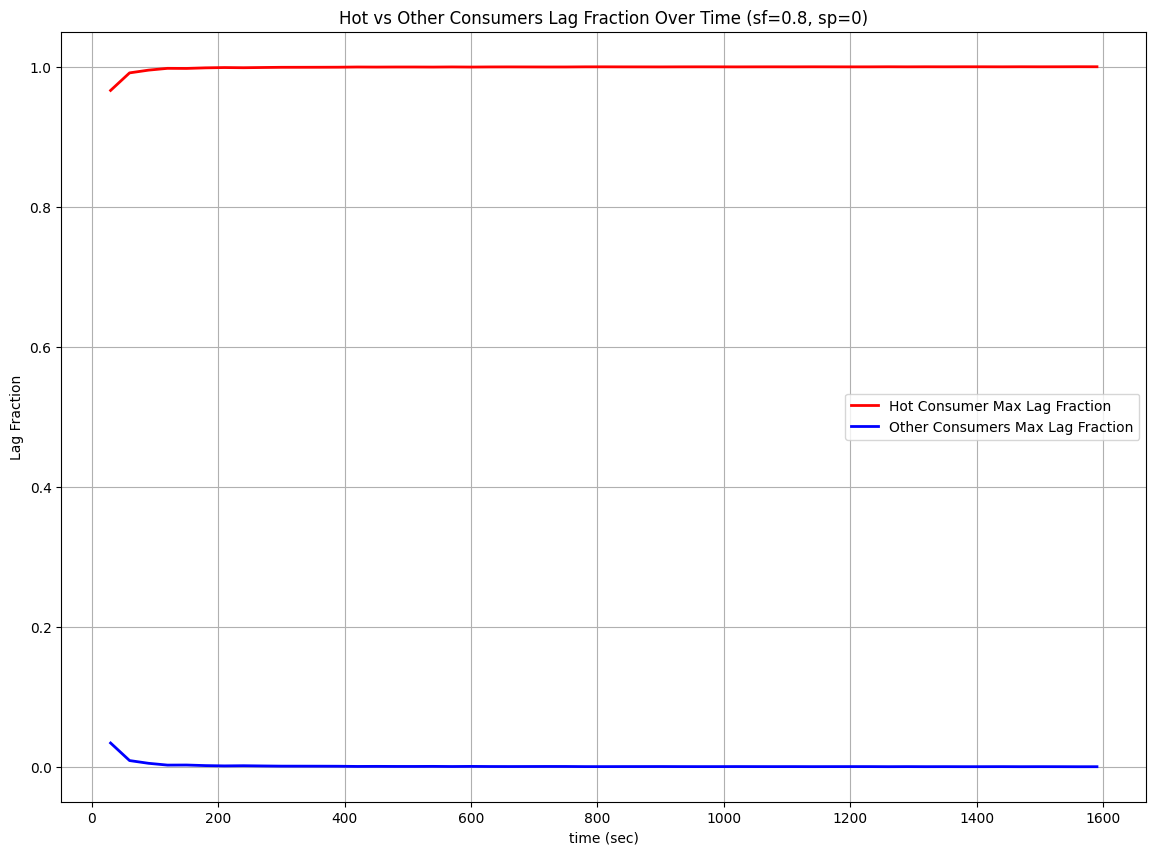

<Figure size 1400x1000 with 0 Axes>

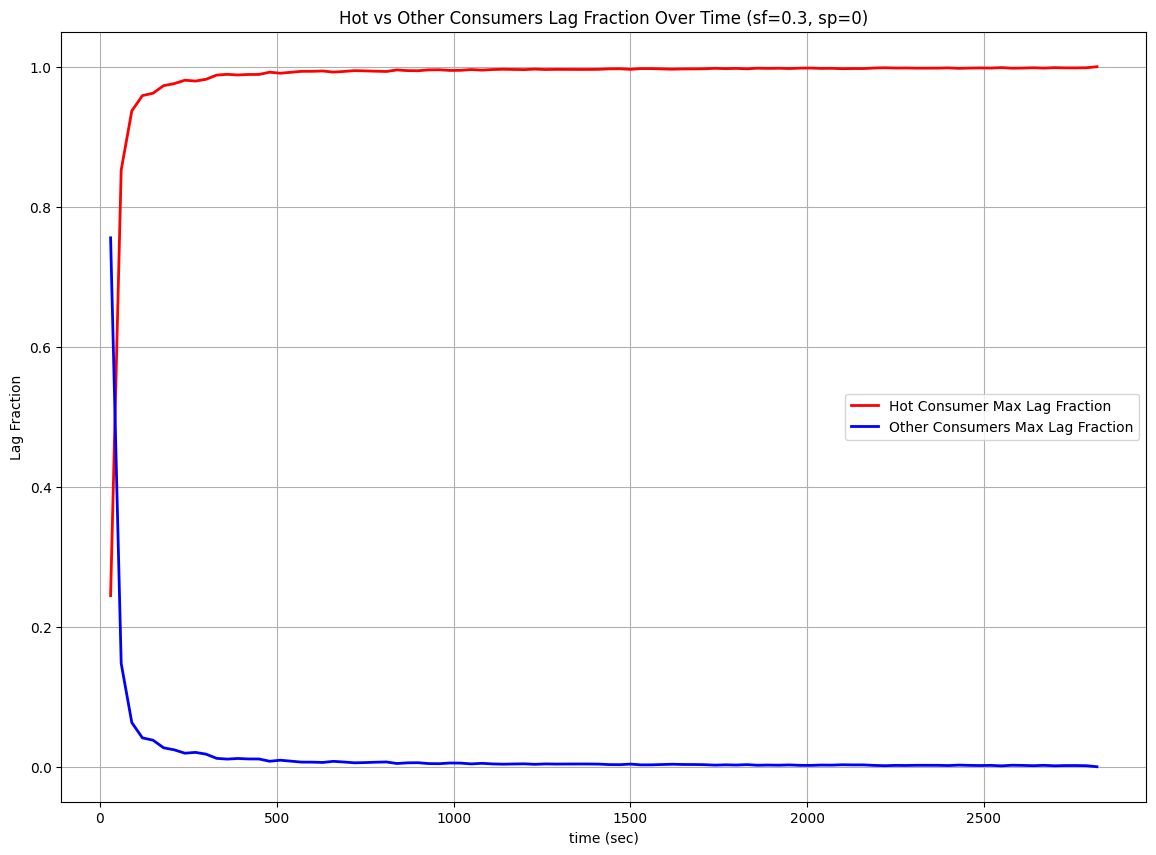

<Figure size 1400x1000 with 0 Axes>

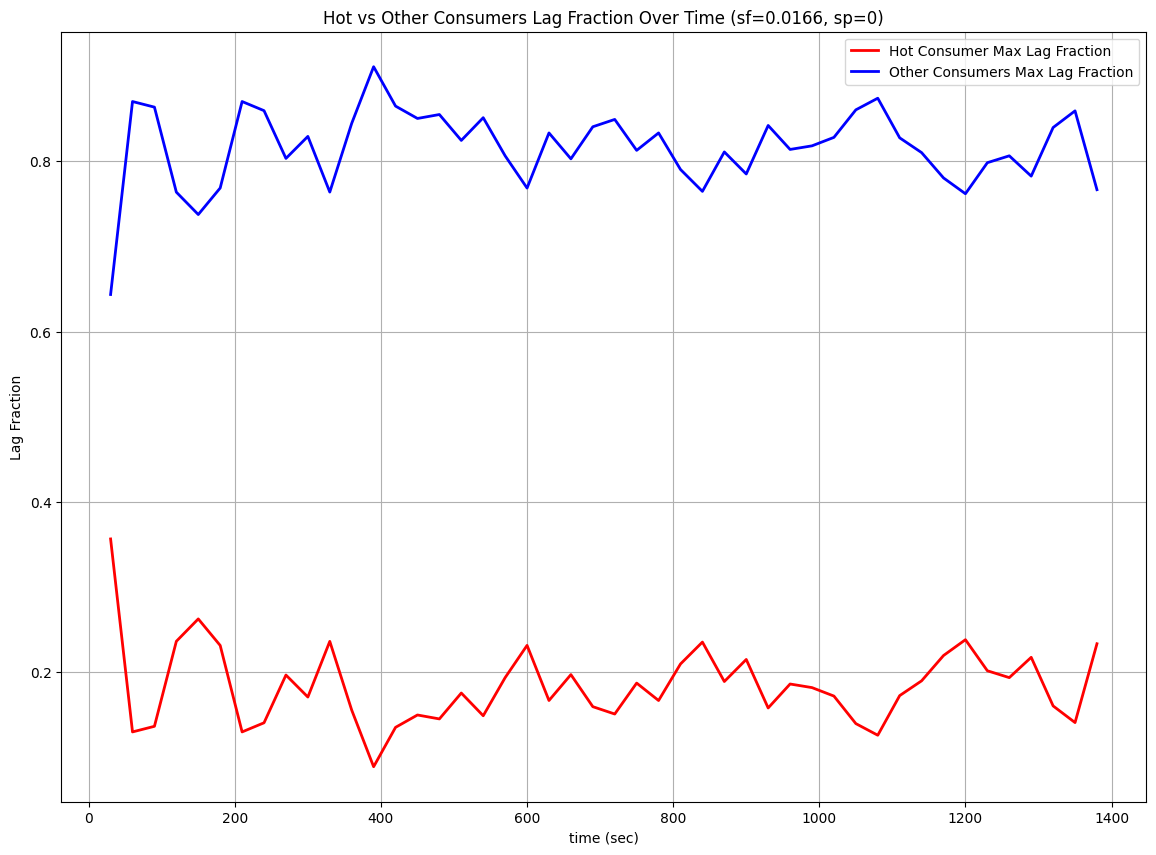

<Figure size 1400x1000 with 0 Axes>

In [12]:
run_ids = ["20260224_125410","20260224_055611","20260224_025555", "20260224_010612","20260223_235807","20260223_232437", "20260224_003023"]
root_dir = Path(f"../results/").resolve()
skew_avg_ls = []
skew_frac_ls  = []
skew_dict = {}
colors = cm.tab20(np.linspace(0, 1, len(run_ids)))

plt.figure(figsize=(14, 10))

for i, run in enumerate (run_ids):

    cfg_path_list = list(root_dir.glob(f"{run}_*/consumer/pipeline-configmap.yaml"))
    cfg_path = cfg_path_list[0]
    csv_per_messages = root_dir.glob(f"{run}_*/consumer/consumer-sts-*_metrics/per_message_latency_run-*_consumer-sts-*.csv")
    csv_files_messages = list(csv_per_messages)
    
    csv_consumers = root_dir.glob(f"{run}_*/consumer/consumer-sts-*_metrics/consumer_metrics_run-*_consumer-sts-*.csv")
    csv_files_consumer = list(csv_consumers)
    
    df_per_messages = pd.concat(map(pd.read_csv, csv_files_messages), ignore_index = True)
    df_consumers = pd.concat([pd.read_csv(f) for f in csv_files_consumer], ignore_index = True)

    # --- Aggregate cluster-level time series ---
    # window size (seconds)
    win = float(df_consumers["lat_window_seconds"].mode().iloc[0])
    df_consumers["t_bucket"] = (np.floor(df_consumers["uptime_sec"] / win) * win).astype(int)

    
    META_RUN = read_cfg(cfg_path)
    tm = META_RUN["traffic_mode"]
    sf = META_RUN["skew_fraction"]
    sp = META_RUN["skew_partitions"]
    

    tag = f"{run}_tm-{tm}_sf-{sf}_sp-{sp}".replace("/", "-").replace(" ", "")

    df_consumers["per_pod_skew"] = df_consumers["max_lag"]/df_consumers["total_lag"]

    out_dir = Path("./max-vs-others") 
    out_dir.mkdir(parents=True, exist_ok = True)
    

    skew_pod_bucket = (
    df_consumers
    .groupby(["t_bucket"], as_index=False)["per_pod_skew"]
    .max()
    )
    

    #skew_pod_bucket["per_pod_skew"]= skew_pod_bucket["max_lag"] / cluster["total_lag"]
    
    cluster = df_consumers.groupby("t_bucket").agg({
    "max_lag": "max",
    "total_lag": "sum"
    }).reset_index()
    
    cluster["cluster_skew"] = cluster["max_lag"] / cluster["total_lag"]
    
    p99_cluster_skew = cluster["cluster_skew"].quantile(0.99)
    #print(p99_cluster_skew, tag )

    # ---- Spillover: impact of hot consumer on others ----
    spillover_rows = []
    
    for t, g in df_consumers.groupby("t_bucket"):
    
        if len(g) < 2:
            continue
    
        hot_idx = g["max_lag"].idxmax()
        hot = g.loc[hot_idx]
    
        others = g.drop(hot_idx)
    
        spillover_rows.append({
            "t_bucket": t,
            "hot_max_lag": hot["max_lag"],
            "hot_total_lag": hot["total_lag"],
            "others_mean_lag": others["total_lag"].mean(),
            "others_sum_lag": others["total_lag"].sum()
        })
    
    spill_df = pd.DataFrame(spillover_rows)

    #spill_df["hot_norm"] = spill_df["hot_max_lag"] / spill_df["hot_max_lag"].max()
    #spill_df["others_norm"] = spill_df["others_mean_lag"] / spill_df["others_mean_lag"].max()

    # max_all = spill_df[["hot_max_lag", "others_mean_lag"]].values.max()
    # spill_df["hot_norm"] = spill_df["hot_max_lag"] / max_all
    # spill_df["others_norm"] = spill_df["others_mean_lag"] / max_all

    # Normalize selected columns using a lambda function with .apply()
    # This scales each column to a range between 0 and 1
    
    #spill_df_normalized_manual = spill_df.apply(lambda x: (x - x.min()) / (x.max() - x.min()))
    bucket_counts = df_consumers.groupby("t_bucket")["pod"].nunique()
    #print(bucket_counts.value_counts().sort_index())

    
    spill_df["others_fraction"] = (
    spill_df["others_sum_lag"] /
    (spill_df["hot_total_lag"] + spill_df["others_sum_lag"])
    )

    spill_df["hot_fraction"] = 1 - spill_df["others_fraction"]
    

    #print(spill_df_normalized_manual)

    # plt.figure(figsize=(14, 8))
    # plt.plot(spill_df["t_bucket"], spill_df["hot_max_lag"], linewidth=2, label="Hot consumer max lag")
    # plt.plot(spill_df["t_bucket"], spill_df["others_mean_lag"], linewidth=2, label="Others mean lag")
    # plt.yscale("symlog")  # handles zeros better than plain log
    # plt.xlabel("time (sec)")
    # plt.ylabel("Lag (symlog scale)")
    # plt.title(f"Spillover over time (sf={sf}, sp={sp})")
    # plt.legend()
    # plt.grid(True)
    # plt.savefig(out_dir / f"spillover_symlog_{tag}.pdf", bbox_inches="tight")

    
    plt.figure(figsize=(14,10))

    plt.plot(spill_df["t_bucket"],
             spill_df["hot_fraction"],
             color="red",
             linewidth=2,
             label="Hot Consumer Max Lag Fraction")
    
    plt.plot(spill_df["t_bucket"],
             spill_df["others_fraction"],
             color="blue",
             linewidth=2,
             label="Other Consumers Max Lag Fraction")
    
    plt.xlabel("time (sec)")
    plt.ylabel("Lag Fraction")
    plt.title(f"Hot vs Other Consumers Lag Fraction Over Time (sf={sf}, sp={sp})")
    plt.legend()
    plt.grid(True)
    
    plt.savefig(out_dir / f"Hot_vs_Other_Cons_Lag_Frac_{tag}.pdf", bbox_inches="tight")
    plt.figure(figsize=(14,10))
    
    # plt.plot(spill_df["t_bucket"],
    #          spill_df["hot_max_lag"],
    #          color="red",
    #          linewidth=2,
    #          label="Hot Consumer Lag")
    
    # plt.plot(spill_df["t_bucket"],
    #          spill_df["others_sum_lag"],
    #          color="blue",
    #          linewidth=2,
    #          label="Other Consumers Sum Lag")
    
    # plt.xlabel("time (sec)")
    # plt.ylabel("Sum Lag")
    # plt.title(f"Hot Consumer vs Others Sum Lag Over Time (sf={sf}, sp={sp})")
    # plt.legend()
    # plt.grid(True)
    
    # plt.savefig(out_dir / f"spillover_sum_lag_{tag}.pdf", bbox_inches="tight")

    # # ---- STD of total lag across consumers per time bucket ----
    # std_lag = (
    #     df_consumers
    #     .groupby("t_bucket")["total_lag"]
    #     .std()
    #     .reset_index(name="std_total_lag")
    # )
    
    # plt.plot(std_lag["t_bucket"], std_lag["std_total_lag"],color=colors[i], linewidth=2, label=f"sf={sf}, sp={sp}")
    
        # ---- Gini of total lag across consumers ----
    # gini_series = (
    #     df_consumers
    #     .groupby("t_bucket")["total_lag"]
    #     .apply(gini)
    #     .reset_index(name="gini_lag")
    # )
    
    # plt.plot(gini_series["t_bucket"], gini_series["gini_lag"],
    #      color=colors[i], linewidth=2,
    #      label=f"sf={sf}, sp={sp}")
    # for pod, g in skew_pod_bucket.groupby("consumer_pod"):
        
    #     plt.plot(g["t_bucket"], g["skew"], label=pod)
    
    #     plt.ylim(0, 1.1)
    #     plt.grid(True)
    #     plt.legend()
    #     plt.show()
    #cluster["cluster_skew_avg"] = cluster["cluster_skew"].mean()
    #print(cluster["cluster_skew_avg"][0])
    #skew_dict [sf] = cluster["cluster_skew_avg"][0]
    #skew_avg_ls.append(cluster["cluster_skew_avg"][0])
    #skew_frac_ls.append(sf)

    
    #plt.plot(cluster["t_bucket"], cluster["cluster_skew"], color=colors[i],label=f"sf={sf}, sp={sp}")
    


    
# plt.xlabel("time (sec)")
# plt.ylabel("Cluster Lag Skew")
# plt.title(f"Cluster Lag Skew Over Time for All Runs. ")
# #plt.axhline(0.8, color='red', linestyle='--', label='Severe Skew')
# plt.legend(ncol=2, fontsize=9)  
# #plt.xlim(0, 4000)
# #plt.ylim(0, 1.1)
# plt.grid(True)
# plt.savefig(out_dir / "Cluster_SKEW_All_Runs .pdf", bbox_inches="tight")


    

In [3]:
df_per_messages.columns

Index(['recv_ts', 'producer_ts', 'e2e_ms', 'topic', 'partition', 'offset',
       'producer_pod', 'index'],
      dtype='object')

Latency Correlation for 20260224_125410_tm-skew_sf-0.05_sp-0
Hot Partition vs Others Mean p99: 0.7527
Hot Partition vs Others Max p99:  0.9189
#########################################
Latency Correlation for 20260224_055611_tm-skew_sf-0.5_sp-0
Hot Partition vs Others Mean p99: 0.3790
Hot Partition vs Others Max p99:  0.6907
#########################################
Latency Correlation for 20260224_025555_tm-skew_sf-0.8_sp-0
Hot Partition vs Others Mean p99: 0.0214
Hot Partition vs Others Max p99:  0.0296
#########################################
Latency Correlation for 20260224_010612_tm-skew_sf-0.3_sp-0
Hot Partition vs Others Mean p99: 0.0682
Hot Partition vs Others Max p99:  0.0469
#########################################
Latency Correlation for 20260223_235807_tm-skew_sf-0.8_sp-0
Hot Partition vs Others Mean p99: 0.2763
Hot Partition vs Others Max p99:  0.4166
#########################################
Latency Correlation for 20260223_232437_tm-skew_sf-0.3_sp-0
Hot Partition vs Ot

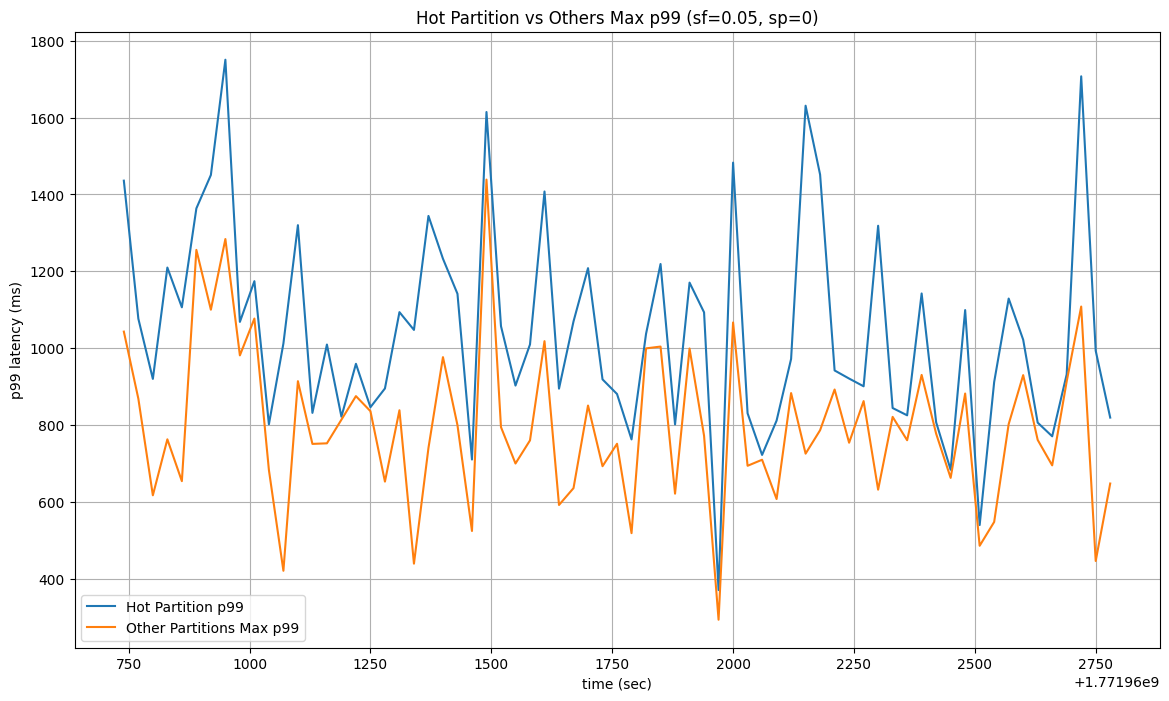

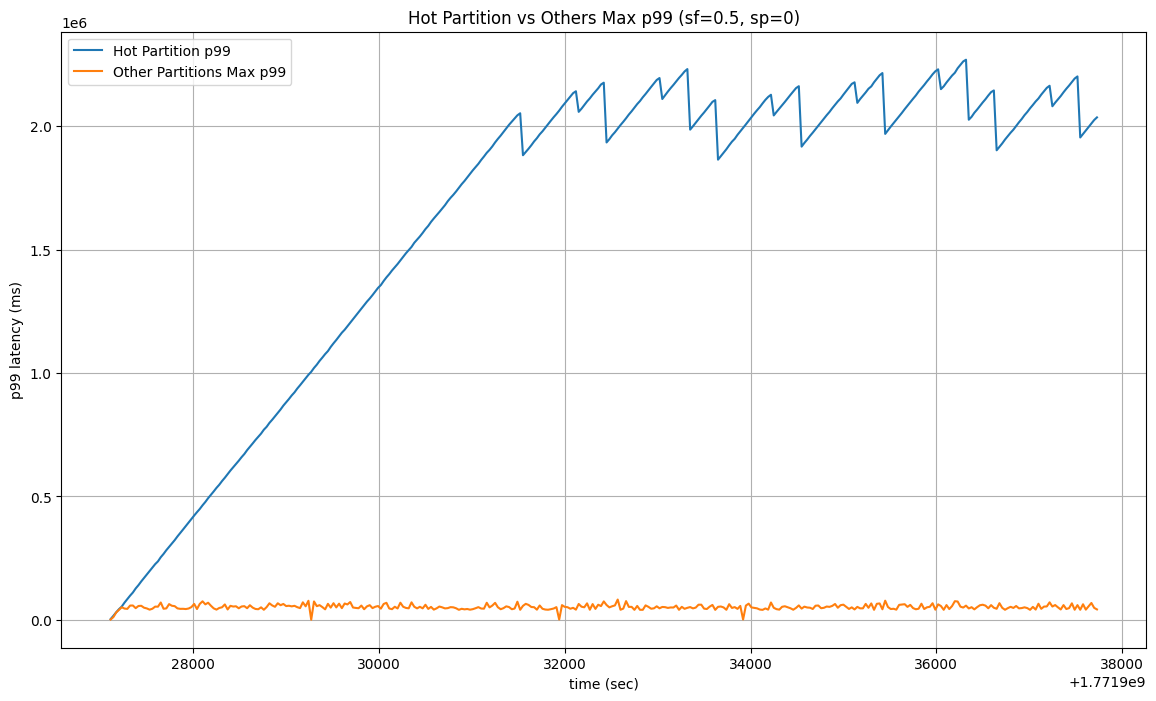

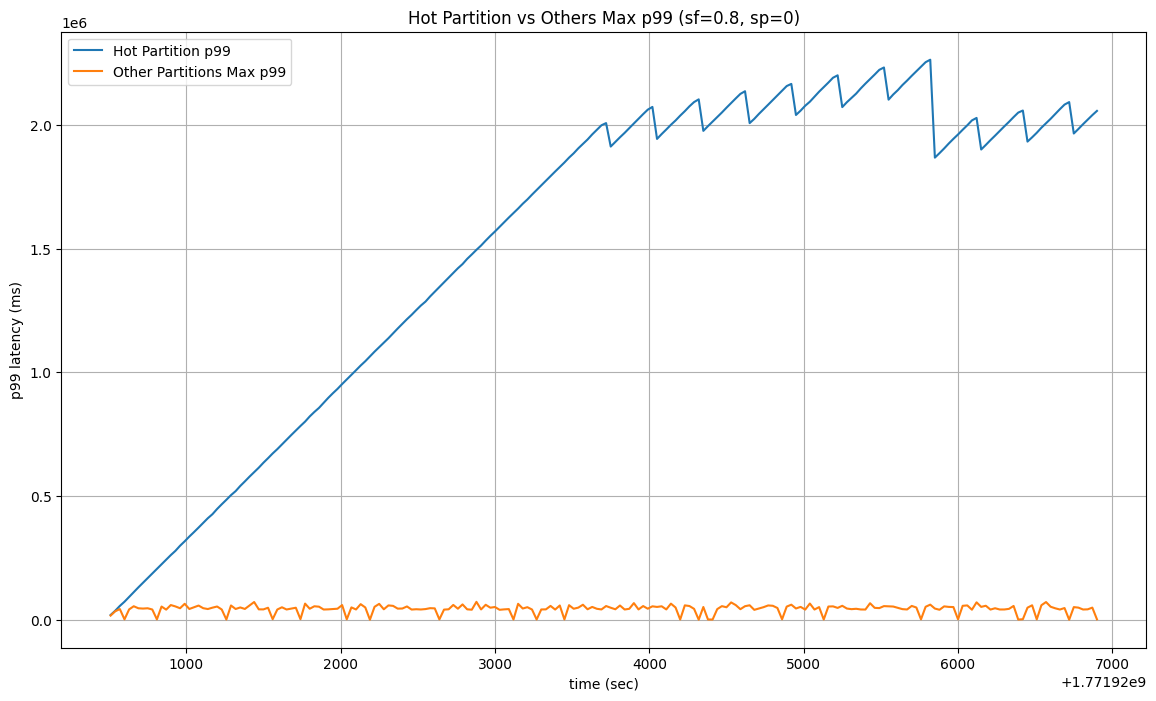

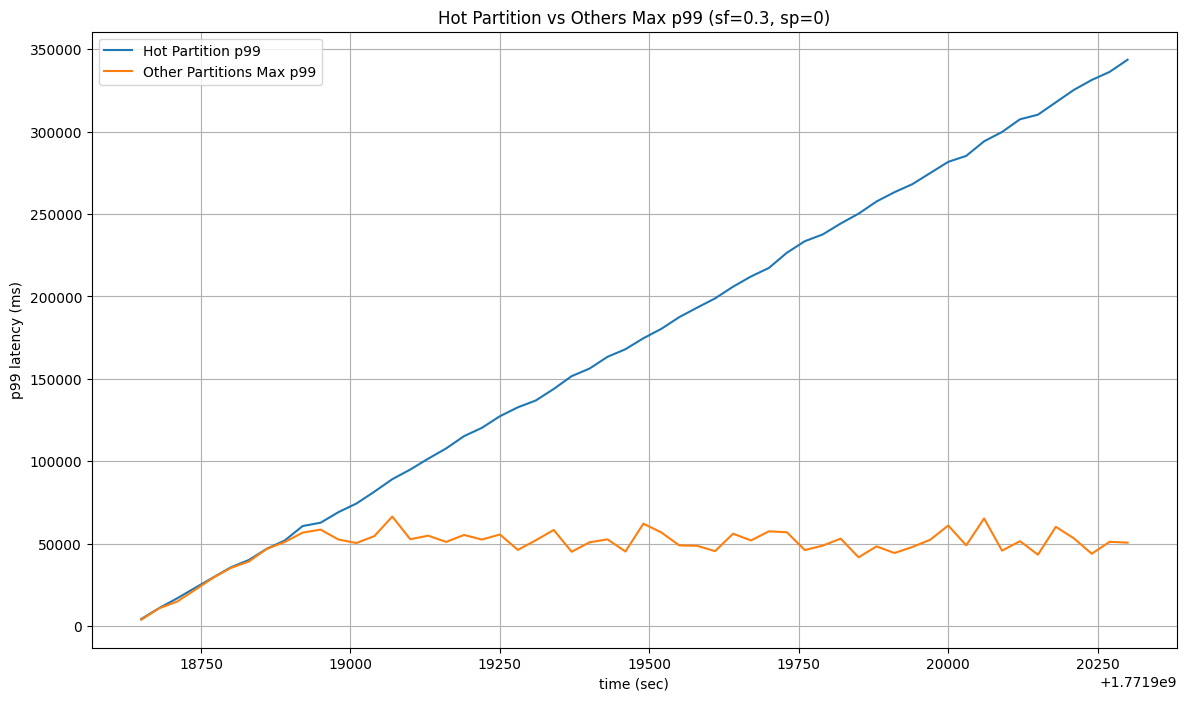

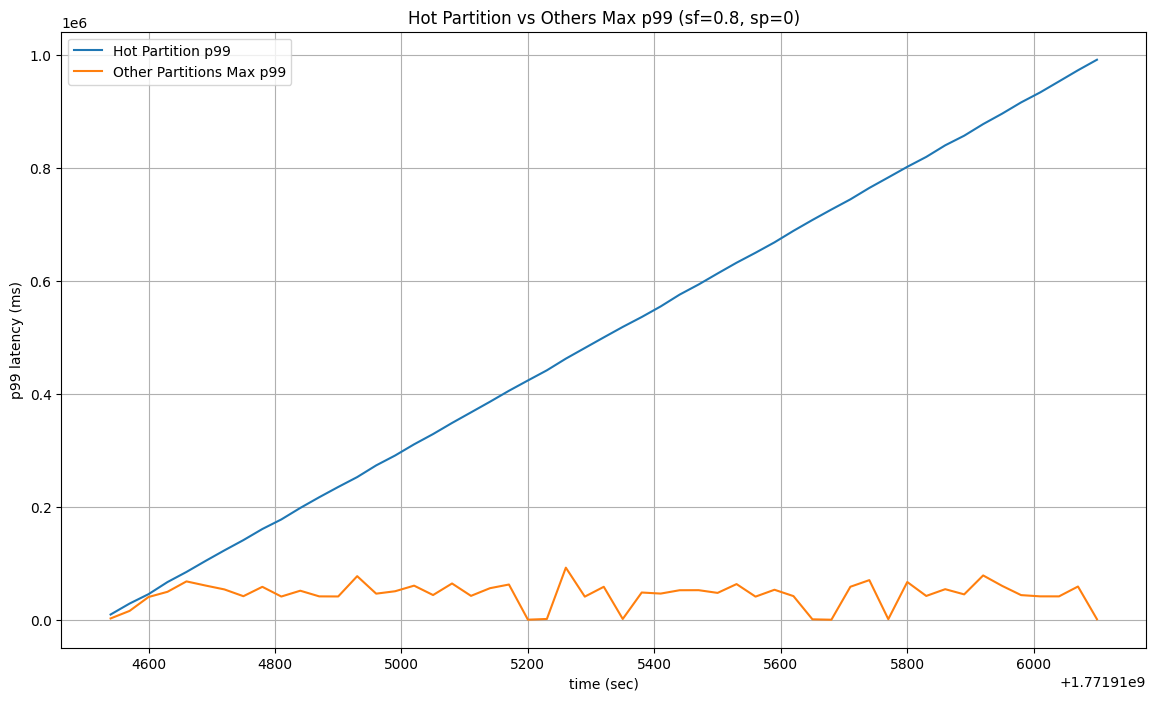

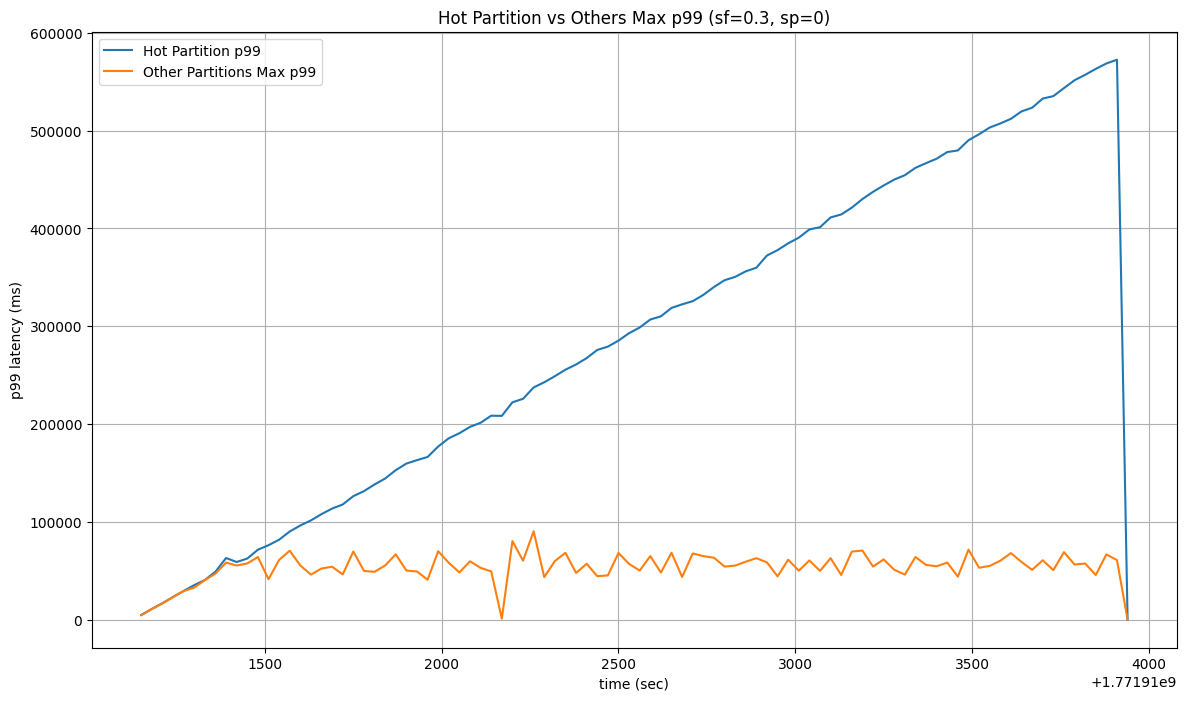

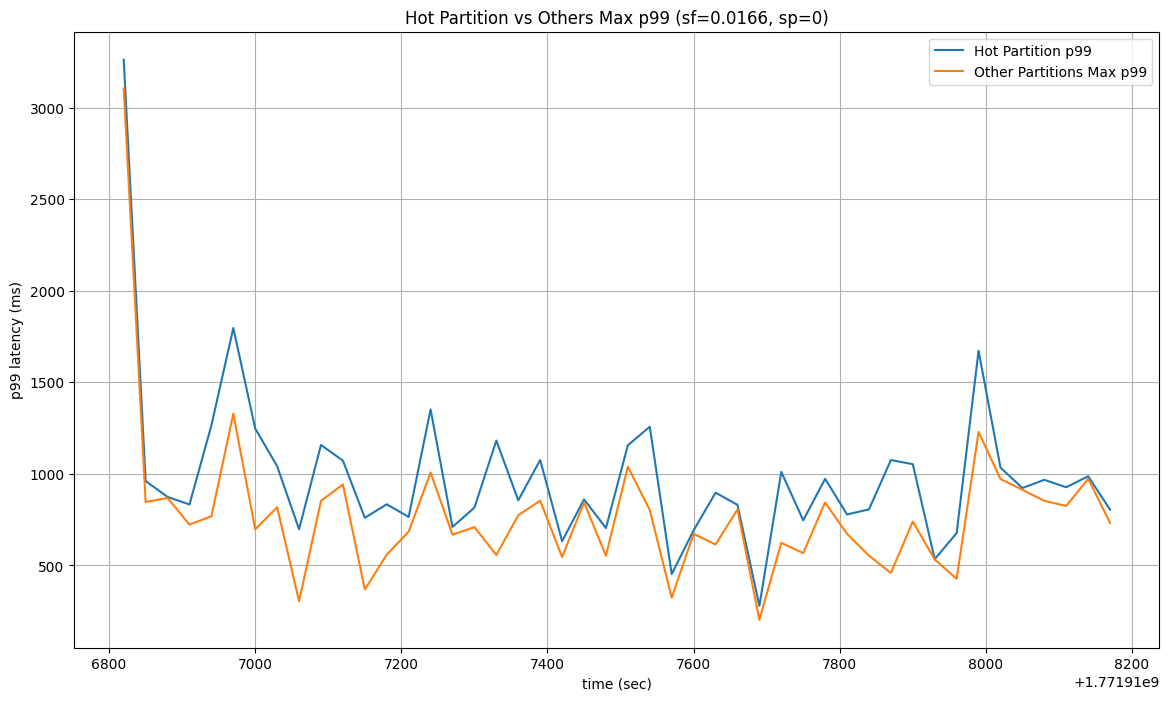

In [11]:
### Compute per-partition latency per window
for i, run in enumerate (run_ids):

    cfg_path_list = list(root_dir.glob(f"{run}_*/consumer/pipeline-configmap.yaml"))
    cfg_path = cfg_path_list[0]
    csv_per_messages = root_dir.glob(f"{run}_*/consumer/consumer-sts-*_metrics/per_message_latency_run-*_consumer-sts-*.csv")
    csv_files_messages = list(csv_per_messages)
    
    csv_consumers = root_dir.glob(f"{run}_*/consumer/consumer-sts-*_metrics/consumer_metrics_run-*_consumer-sts-*.csv")
    csv_files_consumer = list(csv_consumers)
    
    df_per_messages = pd.concat(map(pd.read_csv, csv_files_messages), ignore_index = True)
    df_consumers = pd.concat([pd.read_csv(f) for f in csv_files_consumer], ignore_index = True)

    # --- Aggregate cluster-level time series ---
    # window size (seconds)
    win = float(df_consumers["lat_window_seconds"].mode().iloc[0])
    df_per_messages["t_bucket"] = (
    np.floor(df_per_messages["recv_ts"] / win) * win).astype(int)

    
    META_RUN = read_cfg(cfg_path)
    tm = META_RUN["traffic_mode"]
    sf = META_RUN["skew_fraction"]
    sp = META_RUN["skew_partitions"]
    

    tag = f"{run}_tm-{tm}_sf-{sf}_sp-{sp}".replace("/", "-").replace(" ", "")
    out_dir = Path("./max-vs-others") 
    out_dir.mkdir(parents=True, exist_ok = True)

    # find latency per partition
    part_latency = (
        df_per_messages
        .groupby(["t_bucket", "partition"])["e2e_ms"]
        .quantile(0.99)
        .reset_index()
    )

    hot_rows = (part_latency.sort_values("e2e_ms").groupby("t_bucket").tail(1))
    spill_rows = []

    for t, g in part_latency.groupby("t_bucket"):
    
        if len(g) < 2:
            continue
    
        hot_idx = g["e2e_ms"].idxmax()
        hot = g.loc[hot_idx]
    
        others = g.drop(hot_idx)
    
        spill_rows.append({
            "t_bucket": t,
            "hot_partition": hot["partition"],
            "hot_p99": hot["e2e_ms"],
            "others_mean_p99": others["e2e_ms"].mean(),
            "others_max_p99": others["e2e_ms"].max()
        })

    corr_mean = spill_part_df["hot_p99"].corr(
    spill_part_df["others_mean_p99"]
    )

    corr_max = spill_part_df["hot_p99"].corr(
        spill_part_df["others_max_p99"]
    )

    print(f"Latency Correlation for {tag}")
    print(f"Hot Partition vs Others Mean p99: {corr_mean:.4f}")
    print(f"Hot Partition vs Others Max p99:  {corr_max:.4f}")
    print("#########################################")
    
    spill_part_df = pd.DataFrame(spill_rows)

    plt.figure(figsize=(14,8))

    plt.plot(spill_part_df["t_bucket"],
             spill_part_df["hot_p99"],
             label="Hot Partition p99")
    
    plt.plot(spill_part_df["t_bucket"],
             spill_part_df["others_max_p99"],
             label="Other Partitions Max p99")
    
    plt.xlabel("time (sec)")
    plt.ylabel("p99 latency (ms)")
    plt.title(f"Hot Partition vs Others Max p99 (sf={sf}, sp={sp})")
    plt.legend()
    plt.grid(True)
    plt.savefig(out_dir / f"Hot_Part_Others_Max_p99_{tag}.pdf", bbox_inches="tight")


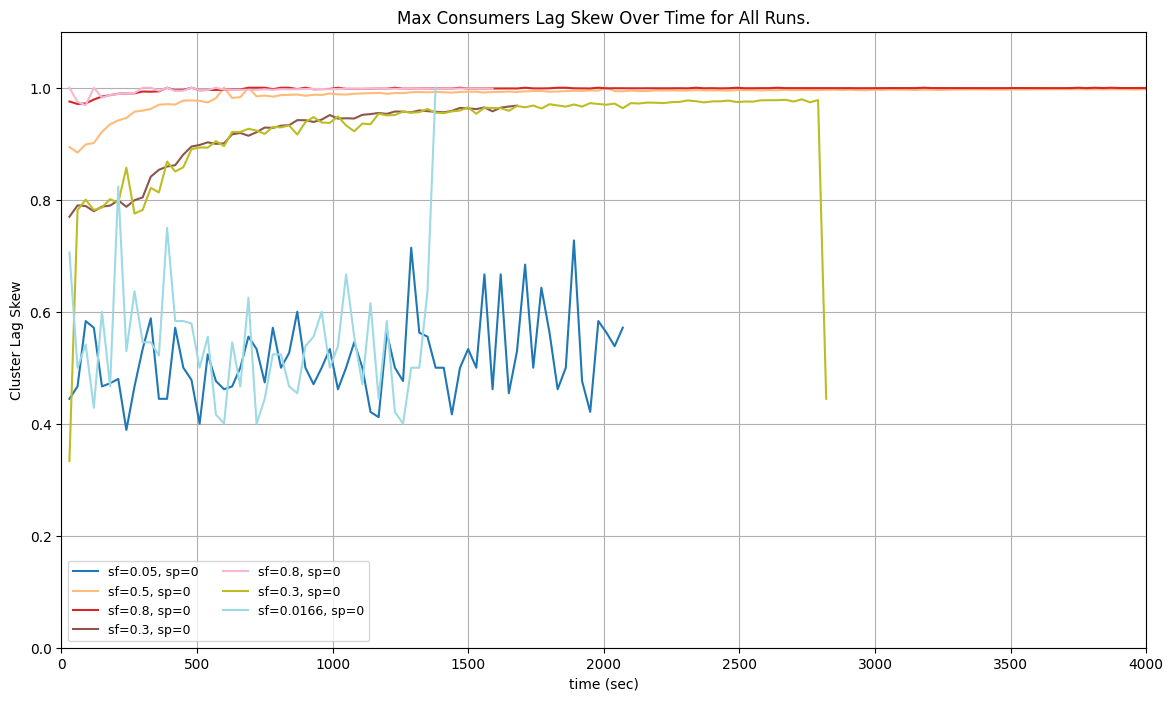

In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

run_ids = ["20260224_125410","20260224_055611","20260224_025555",
           "20260224_010612","20260223_235807","20260223_232437","20260224_003023"]

root_dir = Path("../results/").resolve()
out_dir = Path("./max-total-out")
out_dir.mkdir(parents=True, exist_ok=True)

colors = cm.tab20(np.linspace(0, 1, len(run_ids)))

# ----------------------------
# FIGURE 1: Total lag (cluster)
# ----------------------------
plt.figure(figsize=(14, 8))

for i, run in enumerate(run_ids):
    cfg_path_list = list(root_dir.glob(f"{run}_*/consumer/pipeline-configmap.yaml"))
    cfg_path = cfg_path_list[0]
    csv_per_messages = root_dir.glob(f"{run}_*/consumer/consumer-sts-*_metrics/per_message_latency_run-*_consumer-sts-*.csv")
    csv_files_messages = list(csv_per_messages)
    
    csv_consumers = root_dir.glob(f"{run}_*/consumer/consumer-sts-*_metrics/consumer_metrics_run-*_consumer-sts-*.csv")
    csv_files_consumer = list(csv_consumers)
    
    df_per_messages = pd.concat(map(pd.read_csv, csv_files_messages), ignore_index = True)
    df_consumers = pd.concat([pd.read_csv(f) for f in csv_files_consumer], ignore_index = True)

    # --- Aggregate cluster-level time series ---
    # window size (seconds)
    win = float(df_consumers["lat_window_seconds"].mode().iloc[0])
    df_consumers["t_bucket"] = (np.floor(df_consumers["uptime_sec"] / win) * win).astype(int)

    
    META_RUN = read_cfg(cfg_path)
    tm = META_RUN["traffic_mode"]
    sf = META_RUN["skew_fraction"]
    sp = META_RUN["skew_partitions"]
    

    tag = f"{run}_tm-{tm}_sf-{sf}_sp-{sp}".replace("/", "-").replace(" ", "")

    df_consumers["per_pod_skew"] = df_consumers["max_lag"]/df_consumers["total_lag"]

    out_dir = Path("./max-total-out") 
    out_dir.mkdir(parents=True, exist_ok = True)
    #skew_pod_bucket["skew"] = df_consumers["skew"]

    skew_pod_bucket = (
    df_consumers
    .groupby(["t_bucket"], as_index=False)["per_pod_skew"]
    .max()
    )
    plt.plot(skew_pod_bucket["t_bucket"], skew_pod_bucket["per_pod_skew"], color=colors[i], label=f"sf={sf}, sp={sp}")
    #plt.plot(df_consumers["t_bucket"], df_consumers["skew"], label=f"sf={sf}, sp={sp}")
        
    #plt.figure(figsize=(10,5))
    #plt.plot(df_consumers["t_bucket"], df_consumers["skew"])
    plt.xlabel("time (sec)")
    plt.ylabel("Cluster Lag Skew")
    plt.title(f"Max Consumers Lag Skew Over Time for All Runs.")
    #plt.axhline(0.8, color='red', linestyle='--', label='Severe Skew')
    plt.legend(ncol=2, fontsize=9)  
    plt.xlim(0, 4000)
    plt.ylim(0, 1.1)
    plt.grid(True)
    plt.savefig(out_dir / "Max_Lag_Skew_Consumers_All_Runs.pdf", bbox_inches="tight")
    #plt.show()

In [7]:
part_latency

,t_bucket,partition,e2e_ms
0,1771916820,0,225.765367
1,1771916820,1,25.010347
2,1771916820,2,70.558157
3,1771916820,3,29.025040
4,1771916820,4,23.756504
...,...,...,...
2073,1771918170,43,15.958738
2074,1771918170,44,804.399967
2075,1771918170,50,15.507460
2076,1771918170,53,9.886026


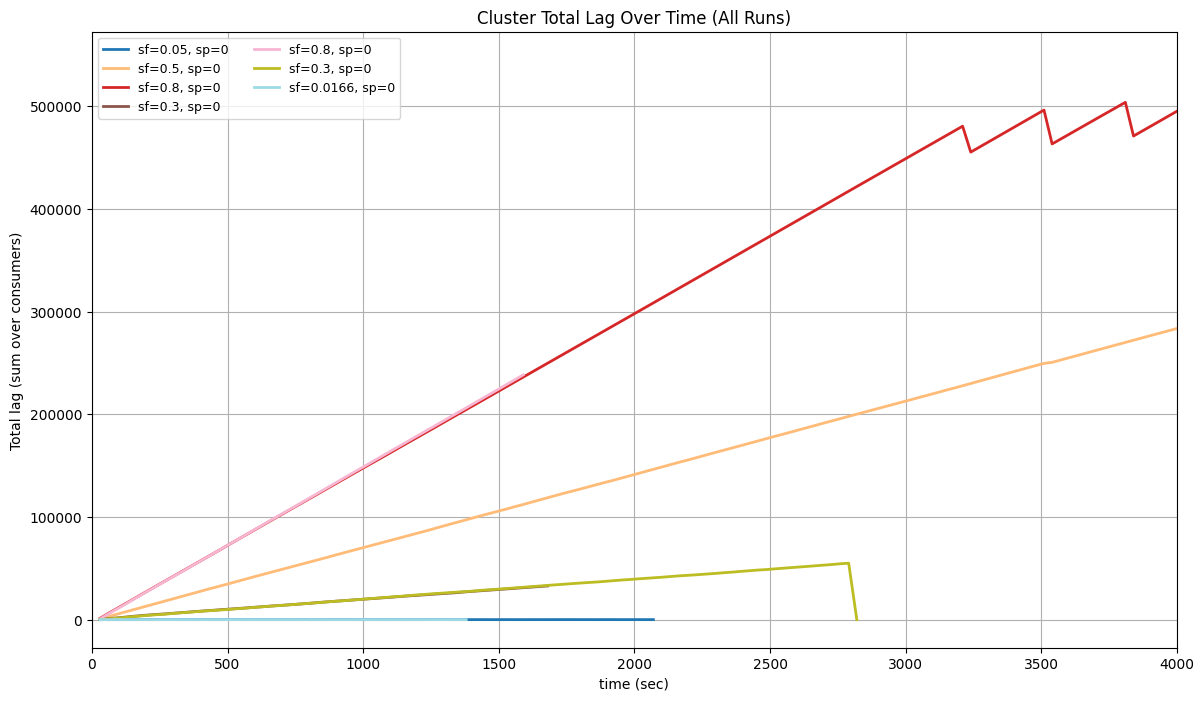

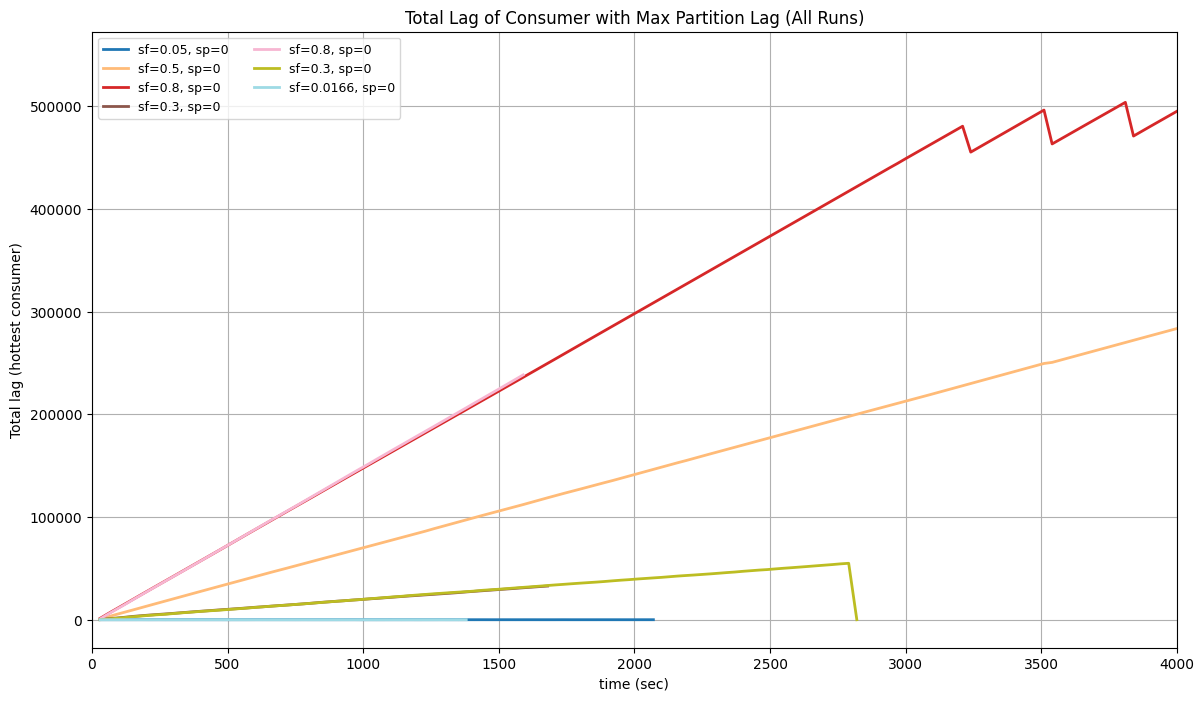

In [108]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

run_ids = ["20260224_125410","20260224_055611","20260224_025555",
           "20260224_010612","20260223_235807","20260223_232437","20260224_003023"]

root_dir = Path("../results/").resolve()
out_dir = Path("./max-total-out")
out_dir.mkdir(parents=True, exist_ok=True)

colors = cm.tab20(np.linspace(0, 1, len(run_ids)))

# ----------------------------
# FIGURE 1: Total lag (cluster)
# ----------------------------
plt.figure(figsize=(14, 8))

for i, run in enumerate(run_ids):
    cfg_path_list = list(root_dir.glob(f"{run}_*/consumer/pipeline-configmap.yaml"))
    if not cfg_path_list:
        print(f"[SKIP] cfg missing for {run}")
        continue
    cfg_path = cfg_path_list[0]

    csv_files_consumer = list(root_dir.glob(
        f"{run}_*/consumer/consumer-sts-*_metrics/consumer_metrics_run-*_consumer-sts-*.csv"
    ))
    if not csv_files_consumer:
        print(f"[SKIP] consumer metrics missing for {run}")
        continue

    df = pd.concat((pd.read_csv(f) for f in csv_files_consumer), ignore_index=True)

    win = float(df["lat_window_seconds"].mode().iloc[0])
    df["t_bucket"] = (np.floor(df["uptime_sec"] / win) * win).astype(int)

    META_RUN = read_cfg(cfg_path)
    sf = META_RUN["skew_fraction"]
    sp = META_RUN["skew_partitions"]

    # (1) cluster total lag = sum of total_lag over all pods per time bucket
    cluster_total = (
        df.groupby("t_bucket", as_index=False)
          .agg(cluster_total_lag=("total_lag", "sum"))
    )

    plt.plot(cluster_total["t_bucket"], cluster_total["cluster_total_lag"],
             color=colors[i], linewidth=2, label=f"sf={sf}, sp={sp}")

plt.xlabel("time (sec)")
plt.ylabel("Total lag (sum over consumers)")
plt.title("Cluster Total Lag Over Time (All Runs)")
plt.xlim(0, 4000)
plt.grid(True)
plt.legend(ncol=2, fontsize=9)
plt.savefig(out_dir / "cluster_total_lag_all_runs.pdf", bbox_inches="tight")
plt.show()


# ----------------------------------------------------
# FIGURE 2: Total lag of the consumer with max max_lag
# ----------------------------------------------------
plt.figure(figsize=(14, 8))

for i, run in enumerate(run_ids):
    cfg_path_list = list(root_dir.glob(f"{run}_*/consumer/pipeline-configmap.yaml"))
    if not cfg_path_list:
        continue
    cfg_path = cfg_path_list[0]

    csv_files_consumer = list(root_dir.glob(
        f"{run}_*/consumer/consumer-sts-*_metrics/consumer_metrics_run-*_consumer-sts-*.csv"
    ))
    if not csv_files_consumer:
        continue

    df = pd.concat((pd.read_csv(f) for f in csv_files_consumer), ignore_index=True)

    win = float(df["lat_window_seconds"].mode().iloc[0])
    df["t_bucket"] = (np.floor(df["uptime_sec"] / win) * win).astype(int)

    META_RUN = read_cfg(cfg_path)
    sf = META_RUN["skew_fraction"]
    sp = META_RUN["skew_partitions"]

    # For each time bucket: find the pod with the largest max_lag
    idx = df.groupby("t_bucket")["max_lag"].idxmax()
    hottest_pod_rows = df.loc[idx, ["t_bucket", "pod", "max_lag", "total_lag"]].sort_values("t_bucket")
    # (2) total lag of the hottest consumer (the one whose max_lag is highest)
    plt.plot(hottest_pod_rows["t_bucket"], hottest_pod_rows["total_lag"],
             color=colors[i], linewidth=2, label=f"sf={sf}, sp={sp}")
#print(df)
plt.xlabel("time (sec)")
plt.ylabel("Total lag (hottest consumer)")
plt.title("Total Lag of Consumer with Max Partition Lag (All Runs)")
plt.xlim(0, 4000)
plt.grid(True)
plt.legend(ncol=2, fontsize=9)
plt.savefig(out_dir / "hottest_consumer_total_lag_all_runs.pdf", bbox_inches="tight")
plt.show()
#print(cluster_total["cluster_total_lag"] - hottest_pod_rows["total_lag"])

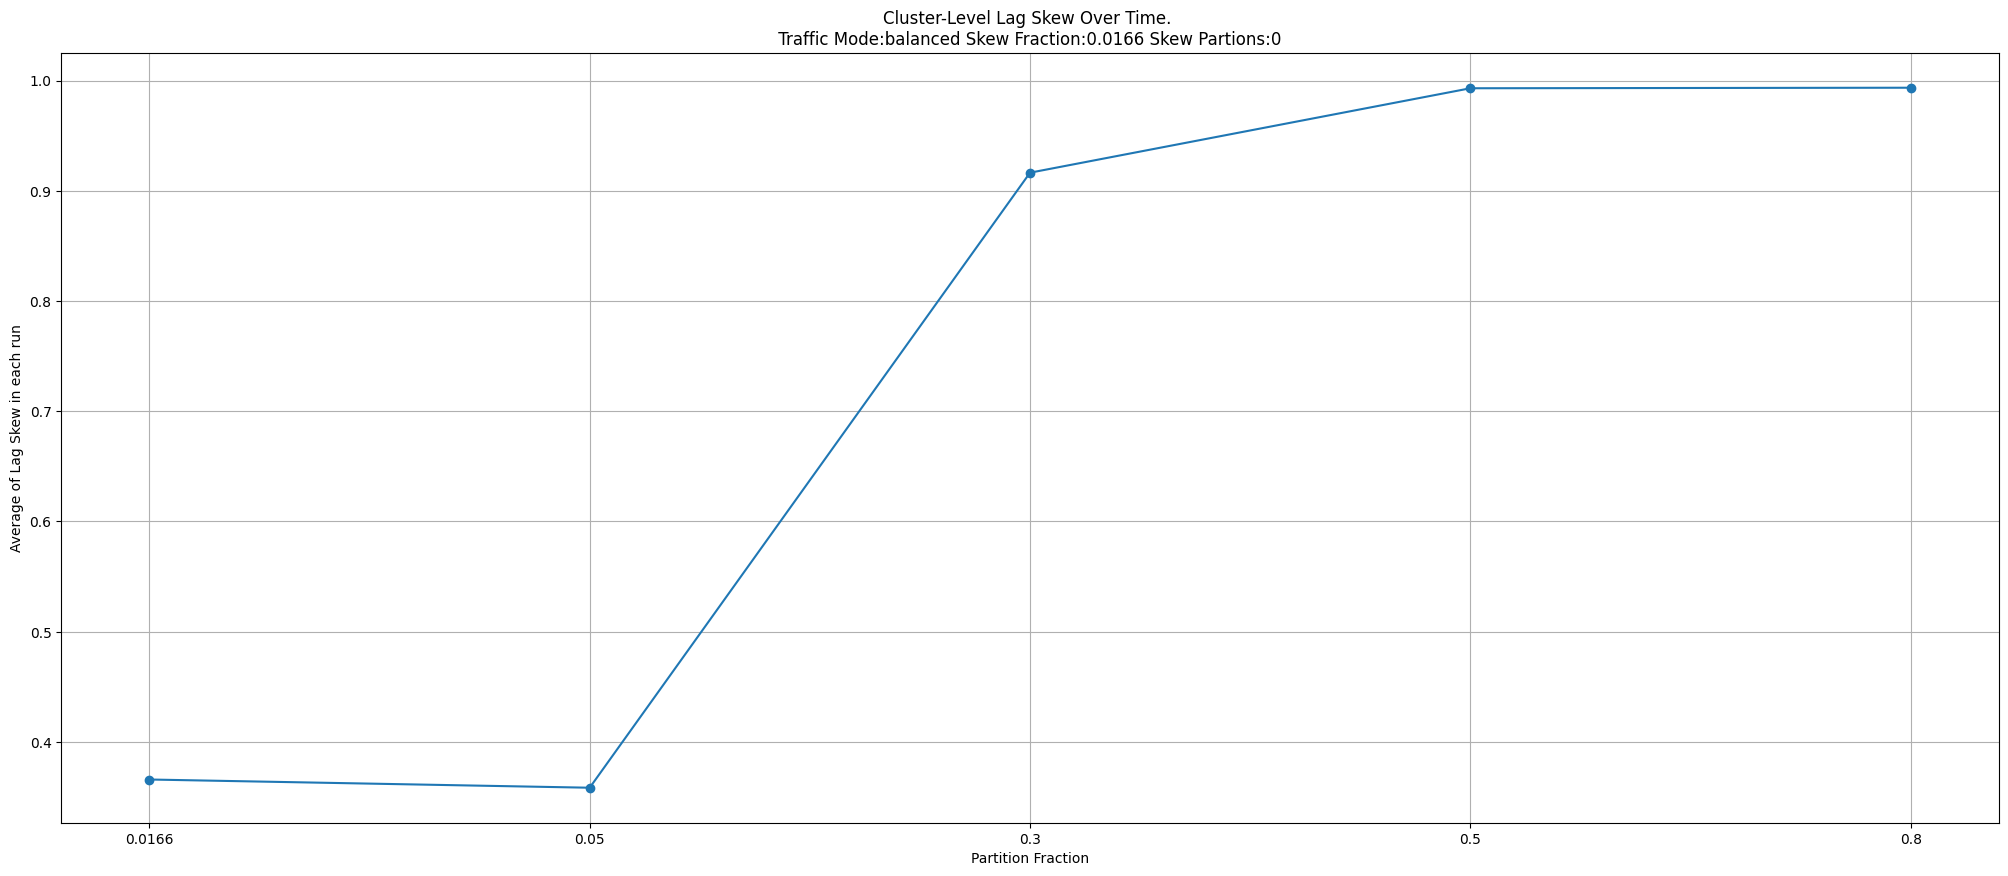

In [283]:
skew_dict_sorted  = dict(sorted(skew_dict.items()))
plt.figure(figsize=(25,10))
plt.plot(skew_dict_sorted.keys(), skew_dict_sorted.values(),  marker='o')
plt.xlabel("Partition Fraction")
plt.ylabel("Average of Lag Skew in each run")
plt.title(f"Cluster-Level Lag Skew Over Time. \n Traffic Mode:{tm} Skew Fraction:{sf} Skew Partions:{sp} ")
plt.grid(True)
plt.savefig(out_dir / f"{tag}.pdf", bbox_inches="tight")
plt.show()